# Assignment 3

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model](https://open.spotify.com/track/4R3AU2pjv8ge2siX1fVbZs?si=b2712f32da0e4358) or a simple [linear regression model](https://scikit-learn.org/stable/modules/linear_model.html)
        - An advanced regressor of your choice (e.g., Random Forest, Neural Network, etc.)

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Assuming that the files `adult.data` and `adult.test` are in `../data/adult/`, then you can use the code below to load them.

In [610]:
import pandas as pd
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = None, names = columns))


In [611]:
fires_dt.head()

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
1,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0,0
2,7,4,oct,tue,90.6,35.4,669.1,6.7,18,33,0.9,0,0
3,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0,0
4,8,6,mar,fri,91.7,33.3,77.5,9,8.3,97,4,0.2,0


In [612]:
fires_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   coord_x  518 non-null    object
 1   coord_y  518 non-null    object
 2   month    518 non-null    object
 3   day      518 non-null    object
 4   ffmc     518 non-null    object
 5   dmc      518 non-null    object
 6   dc       518 non-null    object
 7   isi      518 non-null    object
 8   temp     518 non-null    object
 9   rh       518 non-null    object
 10  wind     518 non-null    object
 11  rain     518 non-null    object
 12  area     518 non-null    object
dtypes: object(13)
memory usage: 52.7+ KB


In [613]:
fires_dt = fires_dt.iloc[1:]
fires_dt.head()

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
1,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0,0
2,7,4,oct,tue,90.6,35.4,669.1,6.7,18,33,0.9,0,0
3,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0,0
4,8,6,mar,fri,91.7,33.3,77.5,9,8.3,97,4,0.2,0
5,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0,0


In [614]:
fires_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 1 to 517
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   coord_x  517 non-null    object
 1   coord_y  517 non-null    object
 2   month    517 non-null    object
 3   day      517 non-null    object
 4   ffmc     517 non-null    object
 5   dmc      517 non-null    object
 6   dc       517 non-null    object
 7   isi      517 non-null    object
 8   temp     517 non-null    object
 9   rh       517 non-null    object
 10  wind     517 non-null    object
 11  rain     517 non-null    object
 12  area     517 non-null    object
dtypes: object(13)
memory usage: 52.6+ KB


In [615]:
fires_dt.describe()

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
count,517,517,517,517,517,517,517,517,517,517,517,517,517
unique,9,7,12,7,106,215,219,119,192,75,21,7,251
top,4,4,aug,sun,92.1,99,745.3,9.6,17.4,27,3.1,0,0
freq,91,203,184,95,28,10,10,23,8,33,53,509,247


In [616]:
fires_dt['area'].describe()

count     517
unique    251
top         0
freq      247
Name: area, dtype: object

In [617]:
#transform area to square root of area, as area is non-linear, and square root of area is linear
fires_dt['area'] = fires_dt['area'].astype(str).astype(float) 
import numpy as np
fires_dt['sqrt_area'] = np.sqrt(fires_dt['area'])
fires_dt

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area,sqrt_area
1,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0,0.00,0.000000
2,7,4,oct,tue,90.6,35.4,669.1,6.7,18,33,0.9,0,0.00,0.000000
3,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0,0.00,0.000000
4,8,6,mar,fri,91.7,33.3,77.5,9,8.3,97,4,0.2,0.00,0.000000
5,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0,6.44,2.537716
514,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0,54.29,7.368175
515,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0,11.16,3.340659
516,1,4,aug,sat,94.4,146,614.7,11.3,25.6,42,4,0,0.00,0.000000


# Get X and Y

Create the features data frame and target data.

In [618]:
from sklearn.model_selection import train_test_split
import numpy as np

X = fires_dt.drop(columns = ['area','sqrt_area'])
Y = fires_dt['sqrt_area']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

###
Steps took:

1.square root 'area' column to transform prediction value to from non-linear to linear

2.for numeric features, based on the histogram and distribution, what transformation should be applied to what features?

3.why describe() results in different parameters, other than quantiles, min, max? (will explore)

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [622]:
# preproc1

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer
# from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_validate


num_cols = ['coord_x', 'coord_y',  'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 
            #'area' , 
       ]

cat_cols = ['month', 'day',
       ]

pipe_num1 = Pipeline([
    ('StandardScaler', StandardScaler()),
    ])


pipe_cat1 = Pipeline([
    ('OneHotEncoder', OneHotEncoder(handle_unknown='infrequent_if_exist', 
                                    #drop='if_binary'
                                    ))])

preproc1 = ColumnTransformer([
    ('num_transforms', pipe_num1, num_cols),
    ('cat_transforms', pipe_cat1, cat_cols),
])

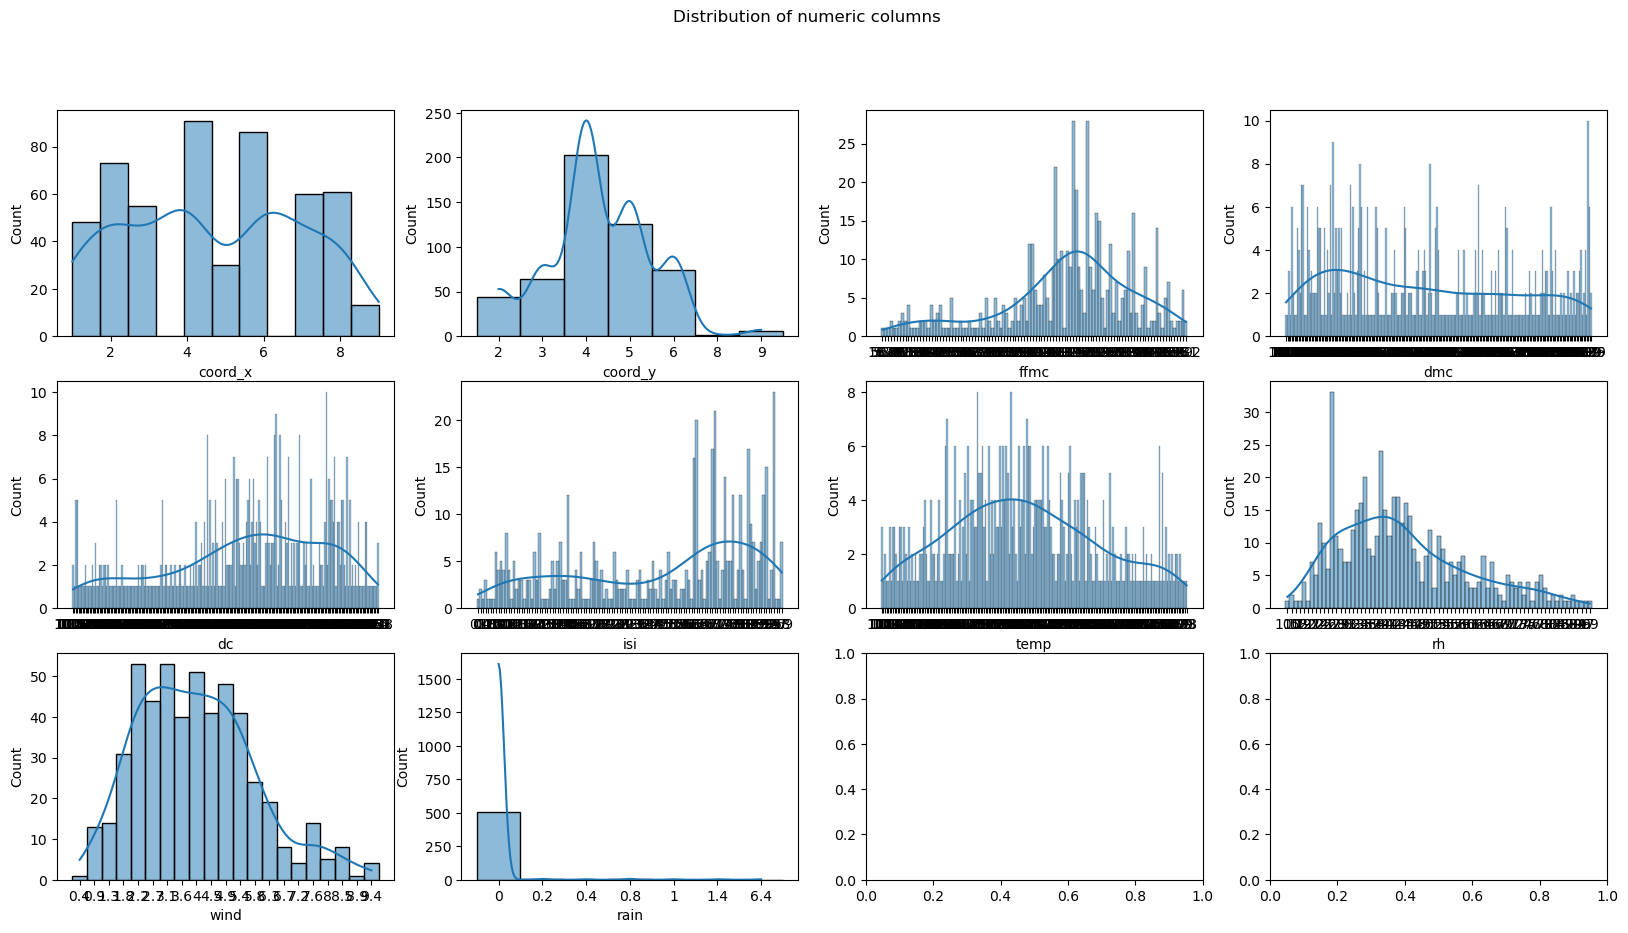

In [665]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(3,4,figsize = (20,10))
fig.suptitle('Distribution of numeric columns')
for i, feature in enumerate(num_cols):
  sns.histplot(X.sort_values(feature)[feature],ax=axes[i//4,i%4],kde=True)

In [692]:
# split num_cols based on the distribution of features, the ones with lots of outliers are going through Quantile Tranformer; 
# remaining ones are going through Power Transfomer

num_cols_power = [
    'coord_x', 'coord_y', 'ffmc', 'temp', 'rh', 'wind','rain'
]
num_cols_quantile = [
  'dmc', 'dc', 'isi'
]

In [625]:
# exploritary charting before and after transforming 'sqrt_area', to see how non-linear transfomers can do
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer

import numpy as np

#ey = np.random.exponential(size=100)
#ey=fires_dt['area'].to_numpy()
ey=fires_dt['sqrt_area'].to_numpy()
#qt = QuantileTransformer(n_quantiles= 200)
qt = PowerTransformer(method='yeo-johnson')

no = qt.fit_transform(ey.reshape(-1, 1))


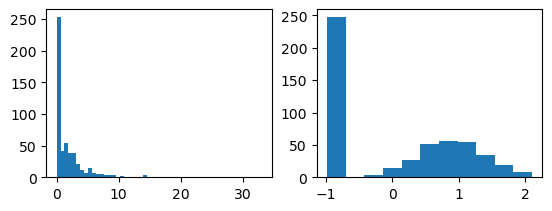

In [627]:
%matplotlib inline 
plt.subplot(2, 2, 1)
plt.hist(ey, bins='auto')
plt.subplot(2, 2, 2)
plt.hist(no, bins='auto')
plt.show()

to do list
1. how to convert 'area' to square root
2. how to split 'area' column based on value, then draw histogram 
3. based on the histogram for numeric features, what transformation should be considered for what features?

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [628]:
# preproc2

pipe_num2 = Pipeline([
    ('transform', PowerTransformer(method='yeo-johnson')),
    ('StandardScaler', StandardScaler())
    ])


pipe_cat2 = Pipeline([
    ('OneHotEncoder', OneHotEncoder(handle_unknown='infrequent_if_exist', 
                                    #drop='if_binary'
                                    ))])

preproc2 = ColumnTransformer([
    ('num_transforms', pipe_num2, num_cols),
    ('cat_transforms', pipe_cat2, cat_cols),
])

In [693]:
# preproc3

pipe_num_power3 = Pipeline([
    ('PowerTransform', PowerTransformer(method='yeo-johnson')),
    ('StandardScaler', StandardScaler())
    ])
pipe_num_quantile3 = Pipeline([
    ('QuantileTransform', QuantileTransformer(n_quantiles=200)),
    ('StandardScaler', StandardScaler())
    ])

pipe_cat3 = Pipeline([
    ('OneHotEncoder', OneHotEncoder(handle_unknown='infrequent_if_exist', 
                                    #drop='if_binary'
                                    ))])

preproc3 = ColumnTransformer([
    ('num_PowerTransforms', pipe_num_power3, num_cols_power),
    ('num_QuantileTransforms', pipe_num_quantile3, num_cols_quantile),
    ('cat_transforms', pipe_cat3, cat_cols),
])

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [629]:
# Pipeline A = preproc1 + baseline

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV

pipeline_A = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', LinearRegression())
])
pipeline_A

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('OneHotEncoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  ['month', 'day'])])),
                ('regressor', LinearRegression())])

In [630]:
scoring = ['neg_root_mean_squared_error', 'explained_variance','neg_mean_absolute_error']
pipe_A_cv = cross_validate(pipeline_A, X_train, Y_train, cv=5, scoring = scoring, return_train_score = True)
pipe_A_cv

{'fit_time': array([0.33599591, 0.11333203, 0.05689597, 0.07499838, 0.07600188]),
 'score_time': array([0.11800361, 0.04800296, 0.0361793 , 0.03500009, 0.04600263]),
 'test_neg_root_mean_squared_error': array([-2.97847135, -2.26346089, -3.57949057, -3.84504106, -2.36735049]),
 'train_neg_root_mean_squared_error': array([-2.6906551 , -2.86081854, -2.72864643, -2.42944097, -2.83669271]),
 'test_explained_variance': array([ 0.01186245, -0.21212971, -0.65540164, -0.03400656, -0.08008623]),
 'train_explained_variance': array([0.0751456 , 0.092755  , 0.08692144, 0.09284806, 0.08292304]),
 'test_neg_mean_absolute_error': array([-1.89794438, -1.76966917, -2.25651616, -2.26469466, -1.67262241]),
 'train_neg_mean_absolute_error': array([-1.76892338, -1.825179  , -1.72370836, -1.69489146, -1.85889566])}

In [631]:
# Pipeline B = preproc2 + baseline

pipeline_B = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', LinearRegression())
])
pipeline_B

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('transform',
                                                                   PowerTransformer()),
                                                                  ('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('OneHotEncoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  ['month', 'day'])])),
                ('regressor', LinearRegression())])

In [632]:
pipe_B_cv = cross_validate(pipeline_B, X_train, Y_train, cv=5, scoring = scoring, return_train_score = True)
pipe_B_cv

{'fit_time': array([0.32999992, 0.28127956, 0.30700397, 0.41699958, 0.45544338]),
 'score_time': array([0.03900814, 0.05900621, 0.06499529, 0.04400182, 0.03199959]),
 'test_neg_root_mean_squared_error': array([-2.98304168, -2.26787829, -2.79761625, -3.80201297, -2.31091692]),
 'train_neg_root_mean_squared_error': array([-2.67046758, -2.84126731, -2.71723486, -2.42374023, -2.82424106]),
 'test_explained_variance': array([ 0.00850923, -0.21648859, -0.01944664, -0.01184359, -0.03235039]),
 'train_explained_variance': array([0.08897158, 0.10511311, 0.09454271, 0.09710037, 0.09095637]),
 'test_neg_mean_absolute_error': array([-1.90837558, -1.76723121, -2.01268683, -2.22120837, -1.60611293]),
 'train_neg_mean_absolute_error': array([-1.74819175, -1.81718106, -1.71962646, -1.68983254, -1.84763399])}

In [694]:
# pipeline_B1 is added after spliting the numerical values into power transformer and quantile transformer
# Pipeline B1 = preproc3 + baseline

pipeline_B1= Pipeline([
    ('preprocessing', preproc3),
    ('regressor', LinearRegression())
])
pipeline_B1

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_PowerTransforms',
                                                  Pipeline(steps=[('PowerTransform',
                                                                   PowerTransformer()),
                                                                  ('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'temp', 'rh', 'wind',
                                                   'rain']),
                                                 ('num_QuantileTransforms',
                                                  Pipeline(steps=[('QuantileTransform',
                                                                   QuantileTransformer(n_quantiles=200)),
                                                                  ('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['dmc', 'dc', 'isi']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('OneHotEncoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  ['month', 'day'])])),
                ('regressor', LinearRegression())])

In [695]:
pipe_B1_cv = cross_validate(pipeline_B1, X_train, Y_train, cv=5, scoring = scoring, return_train_score = True)
pipe_B1_cv

{'fit_time': array([0.09499645, 0.0677886 , 0.07516479, 0.06326652, 0.07882309]),
 'score_time': array([0.02327561, 0.01594496, 0.01381278, 0.03170991, 0.02641749]),
 'test_neg_root_mean_squared_error': array([-2.9851028 , -2.26188141, -2.83436455, -3.83315526, -2.26043898]),
 'train_neg_root_mean_squared_error': array([-2.67982899, -2.84806953, -2.71394888, -2.42160227, -2.84177403]),
 'test_explained_variance': array([ 0.0074242 , -0.20999334, -0.04277755, -0.02837641,  0.01666192]),
 'train_explained_variance': array([0.0825731 , 0.10082312, 0.09673134, 0.09869255, 0.0796346 ]),
 'test_neg_mean_absolute_error': array([-1.90013711, -1.71854897, -2.03365133, -2.23567648, -1.54950417]),
 'train_neg_mean_absolute_error': array([-1.74712552, -1.81568044, -1.70158312, -1.68730067, -1.84008922])}

In [633]:
# Pipeline C = preproc1 + advanced model
from sklearn.ensemble import RandomForestRegressor
pipeline_C = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', RandomForestRegressor())
])
pipeline_C

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('OneHotEncoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor())])

In [634]:
pipe_C_cv = cross_validate(pipeline_C, X_train, Y_train, cv=5, scoring = scoring, return_train_score = True)
pipe_C_cv

{'fit_time': array([2.11055565, 2.74356842, 1.39379025, 1.56834483, 1.52144814]),
 'score_time': array([0.097996  , 0.11100745, 0.06954408, 0.07200336, 0.07700658]),
 'test_neg_root_mean_squared_error': array([-3.24883786, -2.70672595, -2.94063453, -4.04759943, -2.40434784]),
 'train_neg_root_mean_squared_error': array([-1.18769586, -1.26344677, -1.18520533, -1.04605074, -1.26721796]),
 'test_explained_variance': array([-0.16616661, -0.61833128, -0.13193753, -0.14812366, -0.10150991]),
 'train_explained_variance': array([0.82066452, 0.82425051, 0.8287463 , 0.83245756, 0.81876762]),
 'test_neg_mean_absolute_error': array([-2.10571419, -2.06933057, -2.17600146, -2.42868233, -1.64518149]),
 'train_neg_mean_absolute_error': array([-0.79739829, -0.82530464, -0.74647422, -0.70786534, -0.87104697])}

In [635]:
# Pipeline D = preproc2 + advanced model

pipeline_D = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor())
])
pipeline_D

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('transform',
                                                                   PowerTransformer()),
                                                                  ('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('OneHotEncoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  ['month', 'day'])])),
                ('regressor', RandomForestRegressor())])

In [636]:
pipe_D_cv = cross_validate(pipeline_D, X_train, Y_train, cv=5, scoring = scoring, return_train_score = True)
pipe_D_cv

{'fit_time': array([1.66464949, 1.49571943, 1.48277402, 1.47821903, 1.33553696]),
 'score_time': array([0.08911514, 0.07782149, 0.07500505, 0.06899714, 0.06299663]),
 'test_neg_root_mean_squared_error': array([-3.34496155, -2.70859597, -2.85716435, -4.03117276, -2.42027553]),
 'train_neg_root_mean_squared_error': array([-1.20160526, -1.26457648, -1.20033414, -1.00532911, -1.25582494]),
 'test_explained_variance': array([-0.23287164, -0.66628087, -0.0677861 , -0.13914878, -0.12083935]),
 'train_explained_variance': array([0.81641334, 0.82309108, 0.82498327, 0.84572403, 0.8216325 ]),
 'test_neg_mean_absolute_error': array([-2.20742509, -2.05824176, -2.11008758, -2.39450178, -1.63791624]),
 'train_neg_mean_absolute_error': array([-0.80296251, -0.8143324 , -0.76208925, -0.70050539, -0.86022811])}

In [637]:
pipeline_A.get_params()

{'memory': None,
 'steps': [('preprocessing',
   ColumnTransformer(transformers=[('num_transforms',
                                    Pipeline(steps=[('StandardScaler',
                                                     StandardScaler())]),
                                    ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
                                     'isi', 'temp', 'rh', 'wind', 'rain']),
                                   ('cat_transforms',
                                    Pipeline(steps=[('OneHotEncoder',
                                                     OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                    ['month', 'day'])])),
  ('regressor', LinearRegression())],
 'verbose': False,
 'preprocessing': ColumnTransformer(transformers=[('num_transforms',
                                  Pipeline(steps=[('StandardScaler',
                                                   StandardScaler())]),
                                  ['coord

In [638]:
# param_grid_a is for models with linear regreession: a,b,b1 
param_grid_a = {
    'regressor__copy_X': [True,False],
    'regressor__fit_intercept': [True,False]
    #'regressor__ccp_alpha': [0.0, 0.1, 1, 10],
    #'regressor__criterion': ['squared_error'],
    }

In [639]:
# param_grid_d is for models with random forest regressor: c,d
param_grid_d = {
    'regressor__n_estimators': [100,200,300],
    'regressor__max_depth': [None,5,10],
    'regressor__min_samples_split':[2,5,10]
    #'regressor__ccp_alpha': [0.0, 0.1, 1, 10],
    #'regressor__criterion': ['squared_error'],
    }


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [640]:
from sklearn.model_selection import train_test_split, GridSearchCV



In [641]:
# pipeline_A, grid_cv_a
grid_cv_a = GridSearchCV(
    estimator=pipeline_A, 
    param_grid=param_grid_a, 
    scoring = scoring, 
    cv = 5,
    refit = 'neg_root_mean_squared_error'
    
    )
grid_cv_a.fit(X_train, Y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num_transforms',
                                                                         Pipeline(steps=[('StandardScaler',
                                                                                          StandardScaler())]),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('cat_transforms',
                                                                         Pipeline(steps=[('OneHotEncoder',
                                                                                          OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor', LinearRegression())]),
             param_grid={'regressor__copy_X': [True, False],
                         'regressor__fit_intercept': [True, False]},
             refit='neg_root_mean_squared_error',
             scoring=['neg_root_mean_squared_error', 'explained_variance',
                      'neg_mean_absolute_error'])

In [642]:
grid_results_a = grid_cv_a.cv_results_
grid_results_a = pd.DataFrame(grid_results_a)
grid_results_a.columns
grid_results_a[['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'mean_test_neg_root_mean_squared_error',
       'std_test_neg_root_mean_squared_error',
       'rank_test_neg_root_mean_squared_error',
       'mean_test_explained_variance',
       'std_test_explained_variance', 'rank_test_explained_variance',
       'mean_test_neg_mean_absolute_error', 'std_test_neg_mean_absolute_error',
       'rank_test_neg_mean_absolute_error']].sort_values('rank_test_neg_root_mean_squared_error')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,mean_test_explained_variance,std_test_explained_variance,rank_test_explained_variance,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
1,0.065658,0.019288,0.034577,0.001968,-3.006690,0.635082,1,-0.193392,0.242696,1,-1.973136,0.250182,3
3,0.060583,0.002955,0.033600,0.004030,-3.006690,0.635082,1,-0.193392,0.242696,1,-1.973136,0.250182,3
0,0.066424,0.024764,0.031176,0.003717,-3.006763,0.631328,3,-0.193952,0.242559,3,-1.972289,0.246036,1
2,0.065832,0.011032,0.038043,0.006639,-3.006763,0.631328,3,-0.193952,0.242559,3,-1.972289,0.246036,1


In [643]:
# pipeline_B, grid_cv_b
grid_cv_b = GridSearchCV(
    estimator=pipeline_B, 
    param_grid=param_grid_a, 
    scoring = scoring, 
    cv = 5,
    refit = 'neg_root_mean_squared_error'
    
    )
grid_cv_b.fit(X_train, Y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num_transforms',
                                                                         Pipeline(steps=[('transform',
                                                                                          PowerTransformer()),
                                                                                         ('StandardScaler',
                                                                                          StandardScaler())]),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('cat_transforms',
                                                                         Pipeline(steps=[('OneHotEncoder',
                                                                                          OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor', LinearRegression())]),
             param_grid={'regressor__copy_X': [True, False],
                         'regressor__fit_intercept': [True, False]},
             refit='neg_root_mean_squared_error',
             scoring=['neg_root_mean_squared_error', 'explained_variance',
                      'neg_mean_absolute_error'])

In [644]:
grid_results_b = grid_cv_b.cv_results_
grid_results_b = pd.DataFrame(grid_results_b)
grid_results_b.columns
grid_results_b[['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'mean_test_neg_root_mean_squared_error',
       'std_test_neg_root_mean_squared_error',
       'rank_test_neg_root_mean_squared_error',
       'mean_test_explained_variance',
       'std_test_explained_variance', 'rank_test_explained_variance',
       'mean_test_neg_mean_absolute_error', 'std_test_neg_mean_absolute_error',
       'rank_test_neg_mean_absolute_error']].sort_values('rank_test_neg_root_mean_squared_error')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,mean_test_explained_variance,std_test_explained_variance,rank_test_explained_variance,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.392352,0.215366,0.058321,0.037842,-2.832293,0.557617,1,-0.054324,0.082157,3,-1.903123,0.209710,3
2,0.189975,0.006758,0.034354,0.001044,-2.832293,0.557617,1,-0.054324,0.082157,3,-1.903123,0.209710,3
1,0.185345,0.015552,0.034516,0.002764,-2.832349,0.561314,3,-0.054009,0.082114,1,-1.901384,0.212187,1
3,0.187757,0.021626,0.035407,0.002160,-2.832349,0.561314,3,-0.054009,0.082114,1,-1.901384,0.212187,1


In [696]:
# pipeline_B1, grid_cv_b1
grid_cv_b1 = GridSearchCV(
    estimator=pipeline_B1, 
    param_grid=param_grid_a, 
    scoring = scoring, 
    cv = 5,
    refit = 'neg_root_mean_squared_error'
    
    )
grid_cv_b1.fit(X_train, Y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num_PowerTransforms',
                                                                         Pipeline(steps=[('PowerTransform',
                                                                                          PowerTransformer()),
                                                                                         ('StandardScaler',
                                                                                          StandardScaler())]),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('num_QuantileTransforms',
                                                                         Pipeline(steps=[('QuantileTransform',
                                                                                          QuantileTransformer(n_q...
                                                                         Pipeline(steps=[('OneHotEncoder',
                                                                                          OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor', LinearRegression())]),
             param_grid={'regressor__copy_X': [True, False],
                         'regressor__fit_intercept': [True, False]},
             refit='neg_root_mean_squared_error',
             scoring=['neg_root_mean_squared_error', 'explained_variance',
                      'neg_mean_absolute_error'])

In [697]:
# grid_resultes_b1 is added after spliting the numerical values into power transformer and quantile transformer
grid_results_b1 = grid_cv_b1.cv_results_
grid_results_b1 = pd.DataFrame(grid_results_b1)
grid_results_b1.columns
grid_results_b1[['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'mean_test_neg_root_mean_squared_error',
       'std_test_neg_root_mean_squared_error',
       'rank_test_neg_root_mean_squared_error',
       'mean_test_explained_variance',
       'std_test_explained_variance', 'rank_test_explained_variance',
       'mean_test_neg_mean_absolute_error', 'std_test_neg_mean_absolute_error',
       'rank_test_neg_mean_absolute_error']].sort_values('rank_test_neg_root_mean_squared_error')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,mean_test_explained_variance,std_test_explained_variance,rank_test_explained_variance,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.067869,0.024673,0.023063,0.007871,-2.834989,0.579212,1,-0.051412,0.082279,1,-1.887504,0.238970,3
2,0.077545,0.001846,0.016559,0.010213,-2.834989,0.579212,1,-0.051412,0.082279,1,-1.887504,0.238970,3
1,0.068941,0.010620,0.014482,0.008782,-2.836143,0.584134,3,-0.051900,0.082538,3,-1.885139,0.242441,1
3,0.060878,0.013208,0.022792,0.006350,-2.836143,0.584134,3,-0.051900,0.082538,3,-1.885139,0.242441,1


In [645]:
# pipeline_C, grid_c_cv
grid_cv_c = GridSearchCV(
    estimator=pipeline_C, 
    param_grid=param_grid_d, 
    scoring = scoring, 
    cv = 5,
    refit = 'neg_root_mean_squared_error'
    
    )
grid_cv_c.fit(X_train, Y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num_transforms',
                                                                         Pipeline(steps=[('StandardScaler',
                                                                                          StandardScaler())]),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('cat_transforms',
                                                                         Pipeline(steps=[('OneHotEncoder',
                                                                                          OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor', RandomForestRegressor())]),
             param_grid={'regressor__max_depth': [None, 5, 10],
                         'regressor__min_samples_split': [2, 5, 10],
                         'regressor__n_estimators': [100, 200, 300]},
             refit='neg_root_mean_squared_error',
             scoring=['neg_root_mean_squared_error', 'explained_variance',
                      'neg_mean_absolute_error'])

In [646]:
grid_results_c = grid_cv_c.cv_results_
grid_results_c = pd.DataFrame(grid_results_c)
grid_results_c[['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'mean_test_neg_root_mean_squared_error',
       'std_test_neg_root_mean_squared_error',
       'rank_test_neg_root_mean_squared_error',
       'mean_test_explained_variance',
       'std_test_explained_variance', 'rank_test_explained_variance',
       'mean_test_neg_mean_absolute_error', 'std_test_neg_mean_absolute_error',
       'rank_test_neg_mean_absolute_error']].sort_values('rank_test_neg_root_mean_squared_error')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,mean_test_explained_variance,std_test_explained_variance,rank_test_explained_variance,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
17,5.129614,1.987794,0.273392,0.170202,-2.930993,0.572597,1,-0.130466,0.135521,1,-1.977186,0.249729,2
12,1.847970,0.379963,0.146819,0.016616,-2.941722,0.595481,2,-0.132141,0.117806,2,-1.992929,0.261065,4
15,2.227573,0.499709,0.199537,0.089713,-2.947572,0.549852,3,-0.150252,0.167003,3,-1.977994,0.234823,3
16,2.902009,0.852349,0.169326,0.014724,-2.958368,0.581389,4,-0.151357,0.154540,4,-2.004923,0.268251,8
9,1.206788,0.207206,0.100240,0.033427,-2.963842,0.539721,5,-0.168912,0.215810,6,-1.975544,0.239664,1
14,5.766616,0.982493,0.364054,0.116881,-2.968135,0.561422,6,-0.165289,0.186281,5,-1.998258,0.247211,7
13,2.998307,0.299335,0.305986,0.166224,-2.985278,0.564054,7,-0.179444,0.191941,7,-2.005818,0.252606,9
10,2.130924,0.246130,0.120341,0.033077,-2.985934,0.559418,8,-0.186394,0.217473,10,-1.995801,0.250740,6
11,3.553607,0.258859,0.198465,0.071791,-2.988715,0.552439,9,-0.192042,0.244171,12,-1.994482,0.257549,5
8,5.238239,0.679575,0.220309,0.038728,-3.005397,0.574041,10,-0.180919,0.144910,8,-2.059506,0.254102,14


In [647]:
# pipeline_D, grid_d_cv
grid_cv_d = GridSearchCV(
    estimator=pipeline_D, 
    param_grid=param_grid_d, 
    scoring = scoring, 
    cv = 5,
    refit = 'neg_root_mean_squared_error'
    
    )
grid_cv_d.fit(X_train, Y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num_transforms',
                                                                         Pipeline(steps=[('transform',
                                                                                          PowerTransformer()),
                                                                                         ('StandardScaler',
                                                                                          StandardScaler())]),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('cat_transforms',
                                                                         Pipeline(steps=[('OneHotEncoder',
                                                                                          OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor', RandomForestRegressor())]),
             param_grid={'regressor__max_depth': [None, 5, 10],
                         'regressor__min_samples_split': [2, 5, 10],
                         'regressor__n_estimators': [100, 200, 300]},
             refit='neg_root_mean_squared_error',
             scoring=['neg_root_mean_squared_error', 'explained_variance',
                      'neg_mean_absolute_error'])

In [648]:
grid_results_d = grid_cv_d.cv_results_
grid_results_d = pd.DataFrame(grid_results_d)
grid_results_d[['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'mean_test_neg_root_mean_squared_error',
       'std_test_neg_root_mean_squared_error',
       'rank_test_neg_root_mean_squared_error',
       'mean_test_explained_variance',
       'std_test_explained_variance', 'rank_test_explained_variance',
       'mean_test_neg_mean_absolute_error', 'std_test_neg_mean_absolute_error',
       'rank_test_neg_mean_absolute_error']].sort_values('rank_test_neg_root_mean_squared_error')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,mean_test_explained_variance,std_test_explained_variance,rank_test_explained_variance,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
16,2.173997,0.303858,0.150886,0.046953,-2.944078,0.575542,1,-0.140281,0.138483,1,-1.992625,0.250153,2
17,3.078219,0.310510,0.163797,0.023783,-2.957103,0.579393,2,-0.149215,0.138961,2,-1.993537,0.253495,4
15,1.078909,0.044084,0.071093,0.011562,-2.959624,0.570772,3,-0.153875,0.165331,3,-2.005467,0.251014,8
13,2.100393,0.144080,0.106883,0.009291,-2.959763,0.577651,4,-0.154229,0.161060,4,-1.990476,0.254393,1
14,3.623444,0.899805,0.167644,0.077801,-2.966757,0.572347,5,-0.161621,0.171478,5,-1.993535,0.257154,3
11,3.997759,1.524002,0.237741,0.100369,-2.970660,0.557284,6,-0.169641,0.195882,6,-1.993859,0.248816,5
10,1.921144,0.212556,0.113040,0.026188,-2.991150,0.547628,7,-0.191088,0.218719,11,-1.994586,0.247571,6
12,1.199527,0.170104,0.085201,0.022933,-2.993793,0.567051,8,-0.184232,0.181507,8,-2.008748,0.239980,9
9,0.992646,0.082737,0.063381,0.006125,-2.995593,0.546695,9,-0.196124,0.232815,12,-1.995758,0.249928,7
7,2.259623,0.151445,0.111818,0.016379,-3.004367,0.571165,10,-0.181347,0.149573,7,-2.059843,0.255827,14


In [649]:
grid_cv_a.best_params_

{'regressor__copy_X': True, 'regressor__fit_intercept': False}

In [650]:
grid_cv_b.best_params_

{'regressor__copy_X': True, 'regressor__fit_intercept': True}

In [651]:
grid_cv_c.best_params_

{'regressor__max_depth': 5,
 'regressor__min_samples_split': 10,
 'regressor__n_estimators': 300}

In [652]:
grid_cv_d.best_params_

{'regressor__max_depth': 5,
 'regressor__min_samples_split': 10,
 'regressor__n_estimators': 200}

In [653]:
grid_cv_a.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('OneHotEncoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  ['month', 'day'])])),
                ('regressor', LinearRegression(fit_intercept=False))])

In [654]:
grid_cv_b.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('transform',
                                                                   PowerTransformer()),
                                                                  ('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('OneHotEncoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  ['month', 'day'])])),
                ('regressor', LinearRegression())])

In [655]:
grid_cv_c.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('OneHotEncoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  ['month', 'day'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=5, min_samples_split=10,
                                       n_estimators=300))])

In [656]:
grid_cv_d.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('transform',
                                                                   PowerTransformer()),
                                                                  ('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('OneHotEncoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  ['month', 'day'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=5, min_samples_split=10,
                                       n_estimators=200))])

# Evaluate

+ Which model has the best performance?

model B is has the best performance, as it has the highest 'neg_root_mean_squared_error' (lowest root mean squared error).

# Export

+ Save the best performing model to a pickle file.

In [657]:
import pickle

#specify the file path to save the pickle file
file_path = './grid_cv_b.pkl'

#save the grid_cv_b object to a pickle file
with open(file_path, 'wb') as file:
  pickle.dump(grid_cv_b.best_estimator_,file)

#load the grid_cv_b object from the pickle file
with open(file_path,'rb') as file:
  grid_cv_b_loaded = pickle.load(file)

grid_cv_b_loaded

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num_transforms',
                                                  Pipeline(steps=[('transform',
                                                                   PowerTransformer()),
                                                                  ('StandardScaler',
                                                                   StandardScaler())]),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat_transforms',
                                                  Pipeline(steps=[('OneHotEncoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                  ['month', 'day'])])),
                ('regressor', LinearRegression())])

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [698]:
import shap
#data_transform = grid_cv_b.best_estimator_.named_steps['preprocessing'].transform(X_test)
data_transform = grid_cv_b.best_estimator_.named_steps['preprocessing'].transform(X_train)

#create an explainer object using the best-performing model
explainer = shap.explainers.Linear(
    grid_cv_b.best_estimator_.named_steps['regressor'], 
    data_transform,
    feature_names = grid_cv_b.best_estimator_.named_steps['preprocessing'].get_feature_names_out())

shap_values = explainer(data_transform)


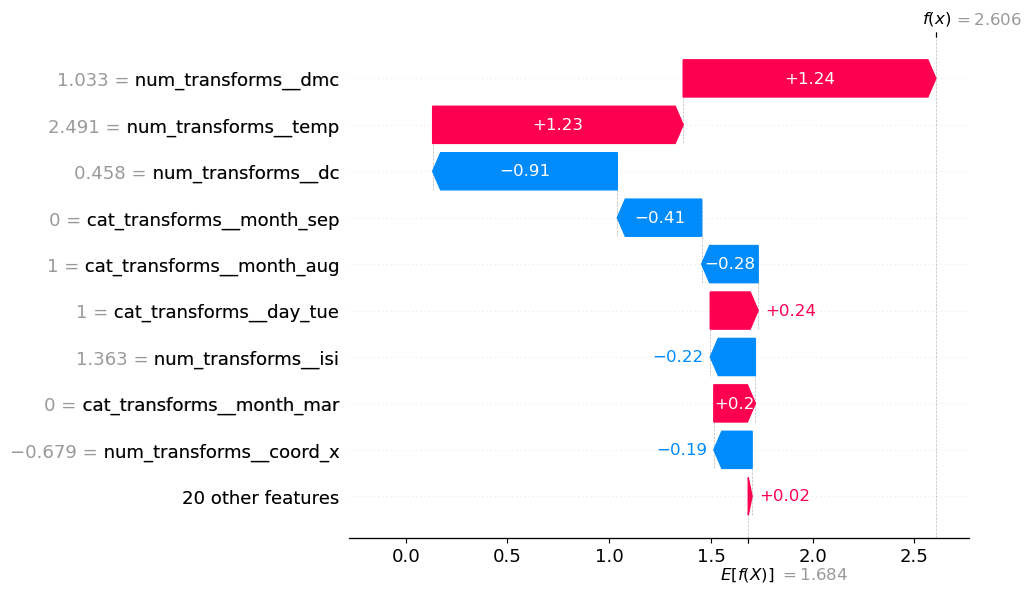

In [704]:
shap.plots.waterfall(shap_values[3])

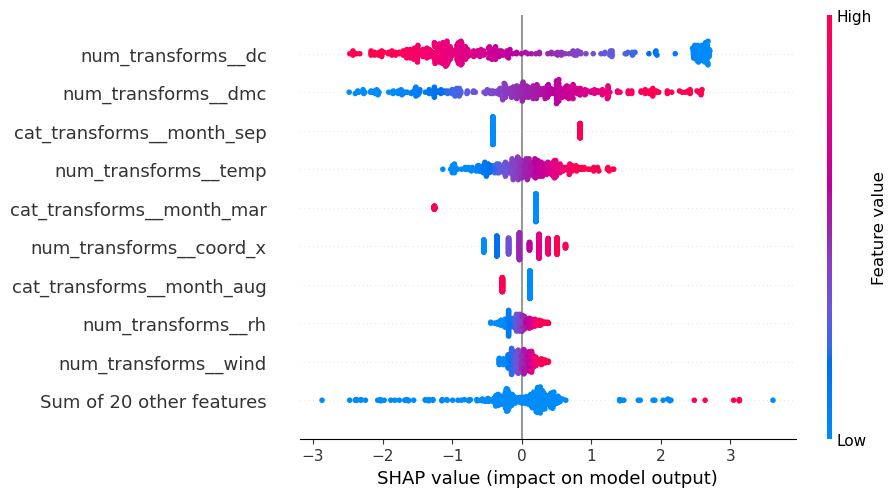

In [700]:
shap.plots.beeswarm(shap_values)

*(Answer here.)*

#### For observation 2, dmc, temperature, dc,month_sep are the most important features. dmc and temp have a positive correlatoin to sqrt_area, whereas others have negative correlation to sqrt_area.

#### In general in training set, the most important features are dc, dmc, month_sep, temp, coord_x, month_mar, month_aug, rh, and wind; the least important features are the remaining ones.

#### If I were to remove features from the models, I would start choosing them from the 20 feautres from the bottom of the chart. I would get the performance metrics using the best performing model to see if the performance can be improved by removing those features.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-3`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_3.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.